Momentum
 ADANIENT         0.065088
BEL              0.042575
Berger_Paints   -0.000700
HCL              0.015172
HDFC             0.005773
Infosys          0.007825
ONGC             0.029873
ShreeCements     0.007247
Tatamotors       0.038979
Trent            0.046511
dtype: float64 

Volatility
               ADANIENT        BEL  Berger_Paints        HCL       HDFC  \
date                                                                     
2021-01-01         NaN        NaN            NaN        NaN        NaN   
2021-01-04         NaN        NaN            NaN        NaN        NaN   
2021-01-05         NaN        NaN            NaN        NaN        NaN   
2021-01-06         NaN        NaN            NaN        NaN        NaN   
2021-01-07         NaN        NaN            NaN        NaN        NaN   
...                ...        ...            ...        ...        ...   
2023-12-22  266.313471  10.989874       7.939326  56.521321  48.420894   
2023-12-26  233.303687  10.985676  

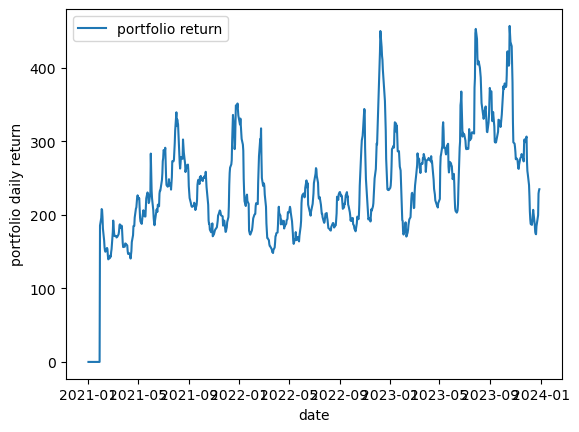

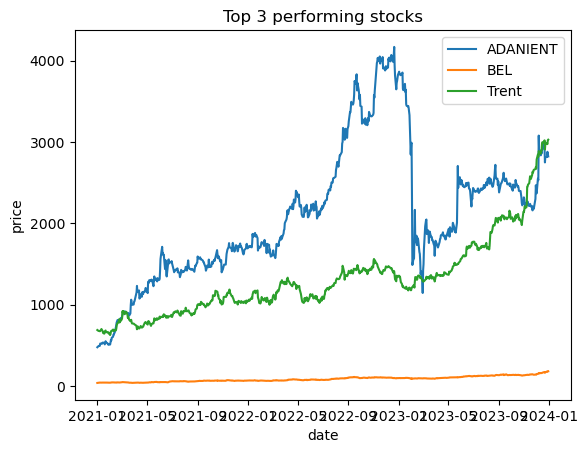

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df1 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/ADANIENT.csv", parse_dates = ['date'])
df1 = df1.set_index('date')[['close']].rename(columns={'close': 'ADANIENT'})
df2= pd.read_csv("/Users/shleshachawla/Downloads/stock_data/BEL.csv", parse_dates = ['date'])
df2 = df2.set_index('date')[['close']].rename(columns={'close': 'BEL'})
df3 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/Berger_Paints.csv", parse_dates = ['date'])
df3 = df3.set_index('date')[['close']].rename(columns={'close': 'Berger_Paints'})
df4 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/HCL_Technologies_Ltd.csv", parse_dates = ['date'])
df4 = df4.set_index('date')[['close']].rename(columns={'close': 'HCL'})
df5 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/HDFC_Bank_Ltd.csv", parse_dates = ['date'])
df5 = df5.set_index('date')[['close']].rename(columns={'close': 'HDFC'})
df6 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/Infosys_Ltd.csv", parse_dates = ['date'])
df6 = df6.set_index('date')[['close']].rename(columns={'close': 'Infosys'})
df7 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/ONGC.csv", parse_dates = ['date'])
df7 = df7.set_index('date')[['close']].rename(columns={'close': 'ONGC'})
df8 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/Shree_Cements_Ltd.csv", parse_dates = ['date'])
df8 = df8.set_index('date')[['close']].rename(columns={'close': 'ShreeCements'})
df9 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/TATAMOTORS.csv", parse_dates = ['date'])
df9 = df9.set_index('date')[['close']].rename(columns={'close': 'Tatamotors'})
df10 = pd.read_csv("/Users/shleshachawla/Downloads/stock_data/TRENT.csv", parse_dates = ['date'])
df10 = df10.set_index('date')[['close']].rename(columns={'close': 'Trent'})
closedf = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10],axis =1)
closedf = closedf.dropna()
#daily return
dailyreturn = closedf.pct_change().dropna()
momentum = closedf.pct_change(20).mean()
print("Momentum\n",momentum,"\n")
volatility = closedf.rolling(20).std()
print("Volatility\n",volatility)
w = momentum/volatility
weight = w/w.sum()
initialcapital = 10000
transactionfee = 0.001
aftercapital = initialcapital*weight*(1- transactionfee)
noofstocks = aftercapital/closedf.iloc[0]
portfoliodailyreturn= (closedf *noofstocks).sum(axis=1)
plt.figure()
plt.plot(portfoliodailyreturn, label = 'portfolio return')
plt.xlabel("date")
plt.ylabel("portfolio daily return")
plt.legend()
bestreturn = closedf.iloc[-1]/closedf.iloc[0] -1
top3 = bestreturn.sort_values(ascending = False).head(3).index
plt.figure()
for i in top3:
    plt.plot(closedf[i] , label = i)
plt.title("Top 3 performing stocks")
plt.xlabel("date")
plt.ylabel("price")
plt.legend()